# Part 2.2 — Synthetic Network Traffic with a GAN (CICIDS 2017)

Here the GAN generates **tabular feature vectors** instead of images — synthetic network-traffic samples that match the real CICIDS 2017 distribution. Core task uses the **Wednesday** file (BENIGN + DoS). Comparison is done with **PCA** and **t-SNE**. The extension at the end uses **all days**.


## 1. Setup

In [ ]:
import os, glob, numpy as np, pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Get the data

Upload your `CICIDS 2017.zip` when prompted, then this unzips it. All 8 daily CSVs land in `cicids/`; the later cells auto-find the Wednesday file.

*If the ~240 MB upload times out,* upload the zip to Google Drive instead and unzip from there (see commented lines).

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

!unzip -o -q "/content/drive/MyDrive/CICIDS 2017.zip" -d cicids

import glob
print("CSV files found:")
for f in glob.glob("cicids/**/*.csv", recursive=True):
    print(" ", f)

Mounted at /content/drive
CSV files found:
  cicids/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  cicids/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  cicids/Tuesday-WorkingHours.pcap_ISCX.csv
  cicids/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  cicids/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  cicids/Wednesday-workingHours.pcap_ISCX.csv
  cicids/Monday-WorkingHours.pcap_ISCX.csv
  cicids/Friday-WorkingHours-Morning.pcap_ISCX.csv


## 3. Load and explore the Wednesday file

The Wednesday capture contains BENIGN traffic plus several DoS attacks. Finding the file automatically, cleaning the column names, and checking the class balance.

In [ ]:
wed_path = [f for f in glob.glob("cicids/**/*.csv", recursive=True) if "ednesday" in f][0]
print("Using:", wed_path)

df = pd.read_csv(wed_path, low_memory=False)
df.columns = df.columns.str.strip()          # CICIDS columns have leading spaces
print("Shape:", df.shape)
print(df["Label"].value_counts())

Using: cicids/Wednesday-workingHours.pcap_ISCX.csv
Shape: (692703, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


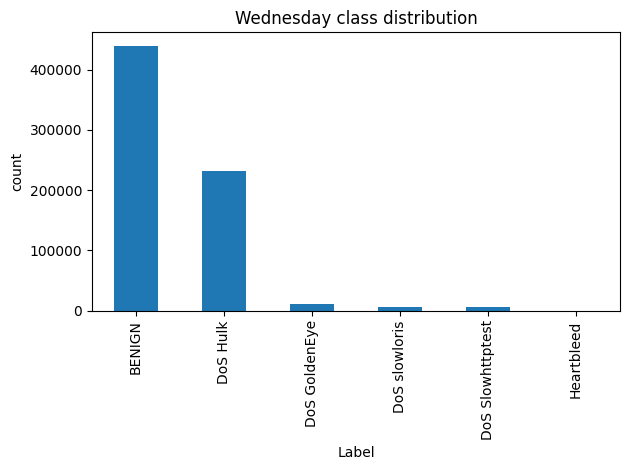

In [ ]:
df["Label"].value_counts().plot(kind="bar")
plt.title("Wednesday class distribution"); plt.ylabel("count"); plt.tight_layout(); plt.show()

## 4. Preprocess

CICIDS has infinities and NaNs (from divide-by-zero rate features), so I replace and drop those. Then I keep the numeric feature columns, scale them to `[0, 1]` (matches the generator's `Sigmoid` output), and subsample to keep training fast. I keep the labels aside so I can colour the plots by attack type later.

In [ ]:
# clean
df = df.replace([np.inf, -np.inf], np.nan).dropna()

y_raw = df["Label"].values
X_df = df.drop(columns=["Label"]).select_dtypes(include=[np.number])
# drop constant (zero-variance) columns
X_df = X_df.loc[:, X_df.std() > 0]
print("Feature columns:", X_df.shape[1])

# subsample for speed
N = min(20000, len(X_df))
idx = np.random.RandomState(42).choice(len(X_df), N, replace=False)
X = X_df.values[idx].astype(np.float32)
y = y_raw[idx]

scaler = MinMaxScaler()
X = scaler.fit_transform(X).astype(np.float32)
n_features = X.shape[1]
print("Training matrix:", X.shape)

X_tensor = torch.tensor(X)
loader = torch.utils.data.DataLoader(X_tensor, batch_size=512, shuffle=True, drop_last=True)

Feature columns: 68
Training matrix: (20000, 68)


## 5. GAN models (MLP)

Both networks are simple fully-connected MLPs since the data is a flat feature vector. Generator: noise → hidden layers → `n_features` outputs with `Sigmoid` (data is in `[0,1]`). Discriminator: feature vector → one real/fake probability.

In [ ]:
latent_dim = 32

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.BatchNorm1d(128), nn.ReLU(True),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(True),
            nn.Linear(256, n_features), nn.Sigmoid(),
        )
    def forward(self, z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.LeakyReLU(0.2, True), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.LeakyReLU(0.2, True), nn.Dropout(0.3),
            nn.Linear(128, 1), nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

## 6. Train

BCE loss, Adam, tracking both losses.

In [ ]:
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

num_epochs = 150
G_losses, D_losses = [], []

for epoch in range(num_epochs):
    for real in loader:
        real = real.to(device); bs = real.size(0)
        # D
        D.zero_grad()
        loss_real = criterion(D(real), torch.ones(bs, 1, device=device))
        z = torch.randn(bs, latent_dim, device=device)
        fake = G(z)
        loss_fake = criterion(D(fake.detach()), torch.zeros(bs, 1, device=device))
        loss_D = loss_real + loss_fake
        loss_D.backward(); opt_D.step()
        # G
        G.zero_grad()
        loss_G = criterion(D(fake), torch.ones(bs, 1, device=device))
        loss_G.backward(); opt_G.step()
    G_losses.append(loss_G.item()); D_losses.append(loss_D.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | D {loss_D.item():.3f} | G {loss_G.item():.3f}")

Epoch  10/150 | D 1.038 | G 1.077
Epoch  20/150 | D 1.109 | G 0.949
Epoch  30/150 | D 1.095 | G 0.987
Epoch  40/150 | D 1.143 | G 0.976
Epoch  50/150 | D 1.228 | G 0.923
Epoch  60/150 | D 1.217 | G 0.896
Epoch  70/150 | D 1.250 | G 0.904
Epoch  80/150 | D 1.256 | G 0.878
Epoch  90/150 | D 1.262 | G 0.874
Epoch 100/150 | D 1.300 | G 0.875
Epoch 110/150 | D 1.291 | G 0.871
Epoch 120/150 | D 1.248 | G 0.869
Epoch 130/150 | D 1.261 | G 0.864
Epoch 140/150 | D 1.237 | G 0.827
Epoch 150/150 | D 1.252 | G 0.853


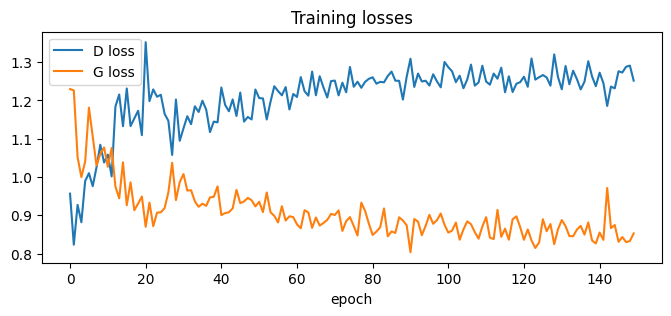

In [ ]:
plt.figure(figsize=(8,3))
plt.plot(D_losses, label="D loss"); plt.plot(G_losses, label="G loss")
plt.xlabel("epoch"); plt.legend(); plt.title("Training losses"); plt.show()

## 7. Compare real vs generated (PCA & t-SNE)

Generate synthetic samples, then project both real and fake into 2D. If the GAN learned the distribution, the two clouds should overlap.

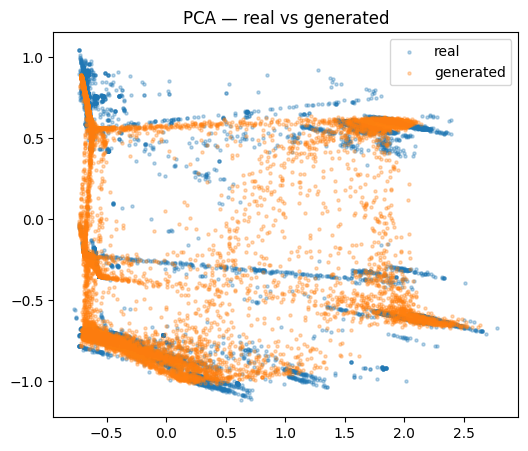

In [ ]:
G.eval()
with torch.no_grad():
    synth = G(torch.randn(N, latent_dim, device=device)).cpu().numpy()
G.train()

# --- PCA (fit on real, apply to both) ---
pca = PCA(n_components=2).fit(X)
real_p, fake_p = pca.transform(X), pca.transform(synth)

plt.figure(figsize=(6,5))
plt.scatter(real_p[:,0], real_p[:,1], s=5, alpha=0.3, label="real")
plt.scatter(fake_p[:,0], fake_p[:,1], s=5, alpha=0.3, label="generated")
plt.legend(); plt.title("PCA — real vs generated"); plt.show()

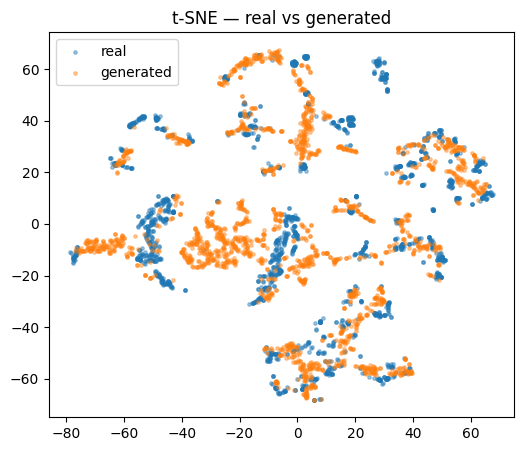

In [ ]:
# --- t-SNE on a subsample (t-SNE is slow) ---
m = 2000
ri = np.random.choice(len(X), m, replace=False)
fi = np.random.choice(len(synth), m, replace=False)
combined = np.vstack([X[ri], synth[fi]])
emb = TSNE(n_components=2, init="pca", random_state=42, perplexity=30).fit_transform(combined)

plt.figure(figsize=(6,5))
plt.scatter(emb[:m,0], emb[:m,1], s=6, alpha=0.4, label="real")
plt.scatter(emb[m:,0], emb[m:,1], s=6, alpha=0.4, label="generated")
plt.legend(); plt.title("t-SNE — real vs generated"); plt.show()

## 8. Evaluation

Training the GAN on the CICIDS dataset helped me understand both the strengths and limitations of GANs when working with tabular network traffic data. From the PCA and t-SNE visualisations, the generated samples followed the general shape of the real data, showing that the generator had learned the main characteristics of the network traffic. However, the synthetic data was more concentrated around the dense regions of the distribution and did not fully capture the sparse attack samples. This is expected because the dataset is highly imbalanced, with benign traffic making up most of the training data.

The generator and discriminator losses remained relatively stable throughout training, suggesting that the adversarial training process converged without either network dominating the other. Although the generated samples were realistic overall, the model showed signs of mild mode collapse, producing fewer examples from the rare attack classes.

Overall, the GAN was successful in generating synthetic network traffic that resembles the majority of the real data, but it struggled to represent uncommon attacks accurately. This highlights one of the main challenges of applying standard GANs to imbalanced cybersecurity datasets.

## 9. Extension — all days + generalisation

Now combine every daily CSV (not just Wednesday) so the data covers many attack types, retrain, and see how well the GAN generalises. Each file is subsampled to keep memory reasonable.

In [ ]:
frames = []
for f in glob.glob("cicids/**/*.csv", recursive=True):
    d = pd.read_csv(f, low_memory=False)
    d.columns = d.columns.str.strip()
    d = d.replace([np.inf,-np.inf], np.nan).dropna()
    frames.append(d.sample(min(15000, len(d)), random_state=42))
full = pd.concat(frames, ignore_index=True)
print("Combined shape:", full.shape)
print(full["Label"].value_counts())

Combined shape: (120000, 79)
Label
BENIGN                        97092
DDoS                           8474
PortScan                       8260
DoS Hulk                       4938
FTP-Patator                     264
DoS GoldenEye                   217
SSH-Patator                     190
Bot                             150
DoS Slowhttptest                133
Web Attack � Brute Force        119
DoS slowloris                   112
Web Attack � XSS                 46
Web Attack � Sql Injection        3
Infiltration                      2
Name: count, dtype: int64


In [ ]:
yf = full["Label"].values
Xf_df = full.drop(columns=["Label"]).select_dtypes(include=[np.number])
Xf_df = Xf_df[X_df.columns]                      # keep same feature columns as before
Xf = MinMaxScaler().fit_transform(Xf_df.values.astype(np.float32)).astype(np.float32)

Nf = min(40000, len(Xf))
ii = np.random.RandomState(0).choice(len(Xf), Nf, replace=False)
Xf, yf = Xf[ii], yf[ii]
loader_f = torch.utils.data.DataLoader(torch.tensor(Xf), batch_size=512, shuffle=True, drop_last=True)

Gf = Generator().to(device); Df = Discriminator().to(device)
opt_Gf = torch.optim.Adam(Gf.parameters(), lr=2e-4, betas=(0.5,0.999))
opt_Df = torch.optim.Adam(Df.parameters(), lr=2e-4, betas=(0.5,0.999))

for epoch in range(150):
    for real in loader_f:
        real = real.to(device); bs = real.size(0)
        Df.zero_grad()
        loss_real = criterion(Df(real), torch.ones(bs,1,device=device))
        z = torch.randn(bs, latent_dim, device=device); fake = Gf(z)
        loss_fake = criterion(Df(fake.detach()), torch.zeros(bs,1,device=device))
        (loss_real+loss_fake).backward(); opt_Df.step()
        Gf.zero_grad()
        criterion(Df(fake), torch.ones(bs,1,device=device)).backward(); opt_Gf.step()
    if (epoch+1)%30==0: print(f"Epoch {epoch+1} done")

Epoch 30 done
Epoch 60 done
Epoch 90 done
Epoch 120 done
Epoch 150 done


### t-SNE coloured by attack type

Overlaying generated samples on the real data, with real points coloured by their attack category, to see which attack clusters the GAN covers.

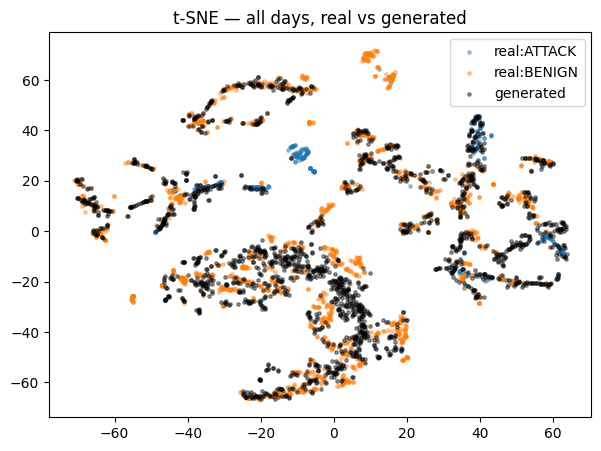

In [ ]:
Gf.eval()
with torch.no_grad():
    synth_f = Gf(torch.randn(2000, latent_dim, device=device)).cpu().numpy()
Gf.train()

m = 2000
ri = np.random.choice(len(Xf), m, replace=False)
combined = np.vstack([Xf[ri], synth_f])
emb = TSNE(n_components=2, init="pca", random_state=42, perplexity=30).fit_transform(combined)

# simplify labels to BENIGN vs attack-family for colouring
labels_sub = np.array(["BENIGN" if l=="BENIGN" else "ATTACK" for l in yf[ri]])
plt.figure(figsize=(7,5))
for lab in np.unique(labels_sub):
    mask = labels_sub==lab
    plt.scatter(emb[:m][mask,0], emb[:m][mask,1], s=6, alpha=0.4, label=f"real:{lab}")
plt.scatter(emb[m:,0], emb[m:,1], s=6, alpha=0.4, c="k", label="generated")
plt.legend(); plt.title("t-SNE — all days, real vs generated"); plt.show()

### Extension discussion

After combining data from all available days, the GAN was exposed to a much wider variety of network traffic and attack types. This made the learning task more challenging because the data contained multiple attack patterns with very different characteristics. The generator was able to learn the overall distribution of the combined dataset, but it still focused mainly on the dominant benign traffic and the larger attack classes. The smaller attack categories remained under-represented, indicating that a single standard GAN does not fully generalise across all attack types in an imbalanced dataset.

GANs are also widely used for generating images, such as handwritten digits, faces or even simple objects like ducks. Although the application is different, the underlying idea is the same: the generator learns the distribution of the training data and produces new samples that resemble it. In cybersecurity, this capability can be used to create realistic synthetic network traffic for research, testing and data augmentation.

Coverage of the rarer attacks could be improved by using techniques such as Conditional GANs (cGANs), which generate samples for specific attack classes, or Wasserstein GANs with Gradient Penalty (WGAN-GP), which generally provide more stable training. Balancing the dataset before training or oversampling minority attack classes would also help the model learn a more representative distribution of all attack types.